# Cursos de Machine Learning en el Sector Bancario
## Modulo 2. `Aprobacion de credito personal`
                        Elaborado por: Naren Castellon

dataset sintético desde cero para predicción de aprobación de crédito personal

# - application_id: ID único de solicitud
# - applicant_id: ID del solicitante (para repetidos)
# - ds: Fecha diaria de solicitud (timestamp)
# - applicant_age: Edad (18-70)
# - annual_income: Ingreso anual (USD)
# - employment_status: Estado laboral ('employed', 'unemployed', 'self-employed')
# - credit_score: Score crediticio (300-850)
# - debt_to_income_ratio: Ratio deuda/ingreso (0-1)
# - loan_amount_requested: Monto solicitado (USD)
# - loan_purpose: Propósito ('home', 'car', 'education', 'personal')
# - marital_status: Estado civil ('single', 'married', 'divorced')
# - num_dependents: Número de dependientes (0-5)
# - residence_type: Tipo de residencia ('own', 'rent', 'family')
# - years_at_current_address: Años en dirección actual (0-20)
# - years_employed: Años empleado (0-40)
# - has_previous_loan: Tiene préstamo previo (0/1)
# - previous_loan_default: Default previo (0/1)
# - bank_account_balance: Saldo bancario (USD)
# - is_approved: Target (0/1, ~60% aprobación con lógica: buen score, bajo DTI, etc.)
# Frecuencia diaria: Una solicitud por solicitante/día en promedio, con variabilidad.

In [8]:
import pandas as pd  # Para manipulación de datos, creación de DataFrames y manejo de series temporales
import numpy as np   # Para generación de datos sintéticos numéricos, operaciones matemáticas y arrays
from datetime import datetime, timedelta  # Para generar fechas diarias secuenciales
import random  # Para selección aleatoria de categorías y variabilidad
import matplotlib.pyplot as plt  # Para visualizaciones básicas como gráficos de dispersión y matrices de confusión
import seaborn as sns  # Para gráficos avanzados en EDA, como heatmaps o distribuciones
from sklearn.model_selection import train_test_split  # Para dividir el dataset en train/test
from sklearn.preprocessing import LabelEncoder, StandardScaler  # Para codificar categóricas y escalar numéricas (importante para ML)
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, precision_recall_curve, auc  # Métricas para evaluar modelo en clases desbalanceadas
from sklearn.ensemble import RandomForestClassifier, StackingClassifier  # RandomForest como base, Stacking para ensemble
from sklearn.linear_model import LogisticRegression  # LogisticRegression como base y meta-learner
from xgboost import XGBClassifier  # XGBoost como base para diversidad en stacking
import warnings
warnings.filterwarnings('ignore')  # Ignorar warnings menores para salida limpia

In [9]:
def generate_credit_approval_data(num_applicants=500, num_days=200):
    """
    Genera dataset sintético de solicitudes de crédito personal con frecuencia diaria.
    - num_applicants: Número de solicitantes únicos.
    - num_days: Días totales (total registros ~ num_applicants * num_days).
    Retorna DataFrame con variables realistas para predicción de aprobación.
    """
    np.random.seed(42)  # Reproducibilidad
    random.seed(42)
    
    data = []
    
    start_date = datetime(2023, 1, 1)  # Inicio para datos recientes
    
    for applicant in range(1, num_applicants + 1):
        applicant_id = f'Applicant_{applicant}'  # ID único
        dates = pd.date_range(start=start_date, periods=num_days, freq='D')  # Fechas diarias
        
        # Generar 0-2 solicitudes por día (para ~100k total)
        daily_apps = np.random.randint(0, 3, num_days)
        
        for i in range(num_days):
            for _ in range(daily_apps[i]):
                # ID solicitud único
                app_id = len(data) + 1
                
                # Edad: Fija por solicitante
                age = random.randint(18, 70)
                
                # Ingreso anual: Lognormal
                income = np.random.lognormal(10.5, 0.5)
                
                # Estado laboral
                employment = random.choice(['employed', 'unemployed', 'self-employed'])
                
                # Score crediticio: Correlacionado con edad/ingreso
                credit_score = 300 + (age / 70 * 200) + (income / 100000 * 350) + np.random.normal(0, 50)
                credit_score = np.clip(credit_score, 300, 850).astype(int)
                
                # DTI ratio: Bajo para altos ingresos
                dti = np.random.uniform(0.1, 0.5) if income > 50000 else np.random.uniform(0.3, 0.8)
                
                # Monto solicitado
                loan_amount = np.random.lognormal(8, 1.5)
                
                # Propósito
                purpose = random.choice(['home', 'car', 'education', 'personal'])
                
                # Estado civil
                marital = random.choice(['single', 'married', 'divorced'])
                
                # Dependientes
                dependents = random.randint(0, 5)
                
                # Residencia
                residence = random.choice(['own', 'rent', 'family'])
                
                # Años en dirección
                years_address = random.randint(0, 20)
                
                # Años empleado
                years_employed = random.randint(0, 40)
                
                # Préstamo previo
                has_prev_loan = random.choice([0, 1])
                
                # Default previo
                prev_default = random.choice([0, 1]) if has_prev_loan else 0
                
                # Saldo bancario
                balance = np.random.normal(2000, 1000) + income * 0.1
                balance = max(balance, 0)
                
                # Aprobación: Lógica (alto score, bajo DTI, no default, etc.)
                approve_prob = 0.6 + 0.2 * (credit_score > 700) - 0.3 * (dti > 0.4) - 0.4 * prev_default + 0.1 * (years_employed > 5)
                # CORRECCIÓN: Usar random.choices en lugar de random.choice (que no soporta 'p' o 'weights')
                is_approved = random.choices([0, 1], weights=[1 - min(approve_prob, 0.99), min(approve_prob, 0.99)], k=1)[0]
                
                data.append({
                    'application_id': app_id,
                    'applicant_id': applicant_id,
                    'ds': dates[i],
                    'applicant_age': age,
                    'annual_income': round(income, 2),
                    'employment_status': employment,
                    'credit_score': credit_score,
                    'debt_to_income_ratio': round(dti, 2),
                    'loan_amount_requested': round(loan_amount, 2),
                    'loan_purpose': purpose,
                    'marital_status': marital,
                    'num_dependents': dependents,
                    'residence_type': residence,
                    'years_at_current_address': years_address,
                    'years_employed': years_employed,
                    'has_previous_loan': has_prev_loan,
                    'previous_loan_default': prev_default,
                    'bank_account_balance': round(balance, 2),
                    'is_approved': is_approved
                })
    
    df = pd.DataFrame(data)
    print(f"Dataset generado: {len(df)} registros con {len(df.columns)} variables (frecuencia diaria).")
    return df

# Generar dataset
credit_df = generate_credit_approval_data(num_applicants=500, num_days=200)  # ~100k registros

# Guardar como CSV (opcional)
credit_df.to_csv('credit_approval_data.csv', index=False)

Dataset generado: 99939 registros con 19 variables (frecuencia diaria).


In [10]:
credit_df = pd.read_csv("./credit_approval_data.csv")
credit_df

,application_id,applicant_id,ds,applicant_age,annual_income,employment_status,credit_score,debt_to_income_ratio,loan_amount_requested,loan_purpose,marital_status,num_dependents,residence_type,years_at_current_address,years_employed,has_previous_loan,previous_loan_default,bank_account_balance,is_approved
0,1,Applicant_1,2023-01-01,58,26072.36,employed,549,0.43,10166.06,home,divorced,2,own,7,8,0,0,3552.63,1
1,2,Applicant_1,2023-01-01,52,24855.55,employed,558,0.80,1536.64,personal,single,0,own,6,14,0,0,4401.39,0
2,3,Applicant_1,2023-01-03,63,67407.26,self-employed,644,0.37,70.24,personal,single,3,family,8,0,0,0,10221.05,1
3,4,Applicant_1,2023-01-03,39,106869.56,unemployed,847,0.13,410.42,car,single,2,own,2,24,0,0,12018.71,1
4,5,Applicant_1,2023-01-04,40,33906.25,self-employed,603,0.79,18528.69,education,single,5,rent,17,7,1,0,5001.17,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99934,99935,Applicant_500,2023-07-12,36,82784.42,employed,665,0.47,1880.13,home,married,5,own,12,11,1,0,10604.08,1
99935,99936,Applicant_500,2023-07-13,54,36947.68,unemployed,532,0.43,163.74,car,divorced,4,own,13,30,0,0,6035.88,0
99936,99937,Applicant_500,2023-07-15,34,64900.56,unemployed,720,0.13,10835.73,personal,divorced,4,own,7,18,0,0,6864.93,1
99937,99938,Applicant_500,2023-07-16,53,46333.54,unemployed,689,0.33,4243.14,personal,married,5,rent,15,36,0,0,5338.21,1


In [11]:
credit_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99939 entries, 0 to 99938
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   application_id            99939 non-null  int64  
 1   applicant_id              99939 non-null  object 
 2   ds                        99939 non-null  object 
 3   applicant_age             99939 non-null  int64  
 4   annual_income             99939 non-null  float64
 5   employment_status         99939 non-null  object 
 6   credit_score              99939 non-null  int64  
 7   debt_to_income_ratio      99939 non-null  float64
 8   loan_amount_requested     99939 non-null  float64
 9   loan_purpose              99939 non-null  object 
 10  marital_status            99939 non-null  object 
 11  num_dependents            99939 non-null  int64  
 12  residence_type            99939 non-null  object 
 13  years_at_current_address  99939 non-null  int64  
 14  years_

In [12]:
# Paso 2: Análisis Exploratorio de Datos (EDA)
# Convertir ds a datetime
credit_df['ds'] = pd.to_datetime(credit_df['ds'])

In [13]:
# Resumen estadístico
print("\nEstadísticas descriptivas:")
print(credit_df.describe())


Estadísticas descriptivas:
       application_id                             ds  applicant_age  \
count    99939.000000                          99939   99939.000000   
mean     49970.000000  2023-04-10 08:17:04.464923648      44.038043   
min          1.000000            2023-01-01 00:00:00      18.000000   
25%      24985.500000            2023-02-20 00:00:00      31.000000   
50%      49970.000000            2023-04-10 00:00:00      44.000000   
75%      74954.500000            2023-05-30 00:00:00      57.000000   
max      99939.000000            2023-07-19 00:00:00      70.000000   
std      28850.048613                            NaN      15.313579   

       annual_income  credit_score  debt_to_income_ratio  \
count   99939.000000  99939.000000          99939.000000   
mean    41025.767063    567.923063              0.485638   
min      4338.930000    300.000000              0.100000   
25%     25926.645000    499.000000              0.360000   
50%     36171.390000    561.0000

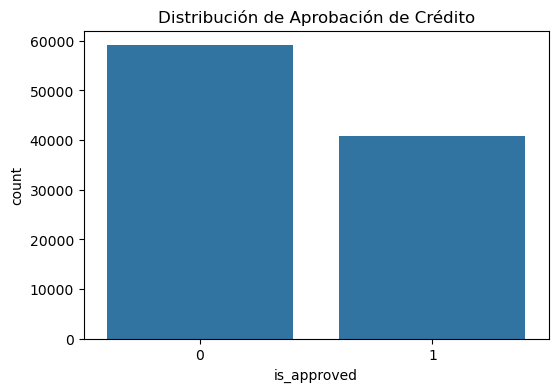

In [14]:
# Distribución de aprobación
plt.figure(figsize=(6, 4))
sns.countplot(x='is_approved', data=credit_df)
plt.title('Distribución de Aprobación de Crédito')
plt.show()

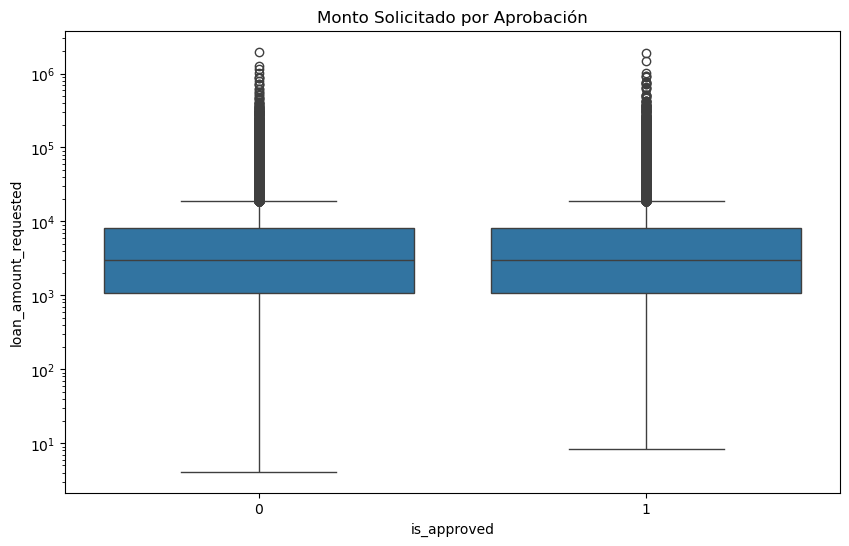

In [15]:
# Monto solicitado por aprobación
plt.figure(figsize=(10, 6))
sns.boxplot(x='is_approved', y='loan_amount_requested', data=credit_df)
plt.yscale('log')
plt.title('Monto Solicitado por Aprobación')
plt.show()

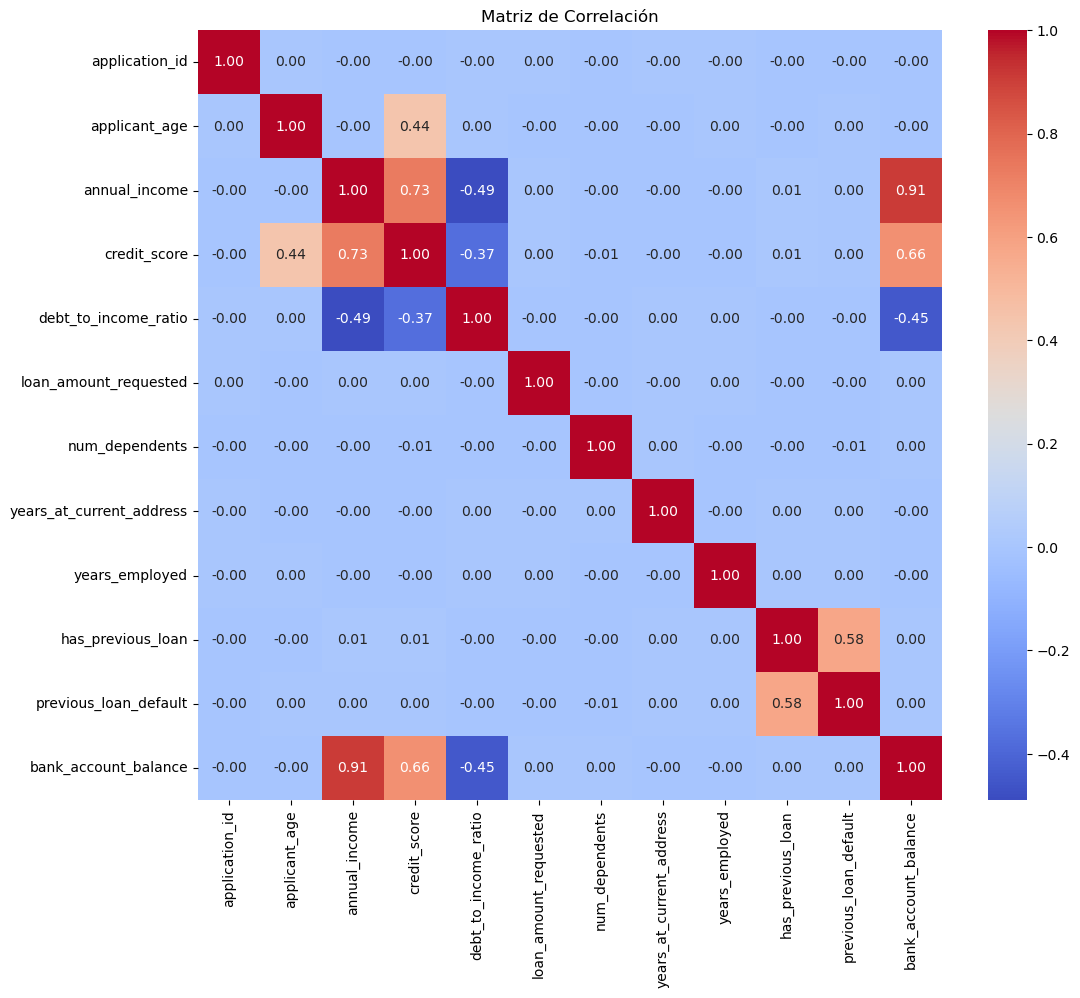

In [16]:
# Correlación numérica
numeric_cols = credit_df.select_dtypes(include=[np.number]).columns.drop('is_approved')
corr_matrix = credit_df[numeric_cols].corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de Correlación')
plt.show()

In [17]:
# Paso 3: Preprocesamiento para Stacking
# Codificar categóricas
cat_cols = ['employment_status', 'loan_purpose', 'marital_status', 'residence_type']
le_dict = {col: LabelEncoder().fit(credit_df[col]) for col in cat_cols}
for col in cat_cols:
    credit_df[col] = le_dict[col].transform(credit_df[col])

In [18]:
# Escalar numéricas
num_cols = ['applicant_age', 'annual_income', 'credit_score', 'debt_to_income_ratio', 'loan_amount_requested', 'num_dependents', 'years_at_current_address', 'years_employed', 'bank_account_balance']
scaler = StandardScaler()
credit_df[num_cols] = scaler.fit_transform(credit_df[num_cols])

In [19]:
# Dividir train/test (estratificado por aprobación)
X = credit_df.drop(columns=['application_id', 'applicant_id', 'ds', 'is_approved'])
y = credit_df['is_approved']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [21]:
# Paso 4: Definir Modelos Base y Stacking
# Stacking: Ensemble donde modelos base (nivel 1) generan predicciones para meta-learner (nivel 2)
# Bases: RandomForest (bagging), XGBoost (boosting), LogisticRegression (lineal) para diversidad
# Meta: LogisticRegression simple para combinar
base_models = [
    ('rf', RandomForestClassifier(n_estimators=100, random_state=42)),
    ('xgb', XGBClassifier(n_estimators=100, random_state=42)),
    ('lr', LogisticRegression(max_iter=1000, random_state=42))
]

meta_model = LogisticRegression(max_iter=1000, random_state=42)

stacking_model = StackingClassifier(estimators=base_models, final_estimator=meta_model, cv=5, n_jobs=-1)  # cv=5 para out-of-fold preds
stacking_model

StackingClassifier(cv=5,
                   estimators=[('rf', RandomForestClassifier(random_state=42)),
                               ('xgb',
                                XGBClassifier(base_score=None, booster=None,
                                              callbacks=None,
                                              colsample_bylevel=None,
                                              colsample_bynode=None,
                                              colsample_bytree=None,
                                              device=None,
                                              early_stopping_rounds=None,
                                              enable_categorical=False,
                                              eval_metric=None,
                                              feature_types=None,
                                              feature_weights=None, gamma=None,
                                              gro...
                                              max_cat_threshold=None,
                                              max_cat_to_onehot=None,
                                              max_delta_step=None,
                                              max_depth=None, max_leaves=None,
                                              min_child_weight=None,
                                              missing=nan,
                                              monotone_constraints=None,
                                              multi_strategy=None,
                                              n_estimators=100, n_jobs=None,
                                              num_parallel_tree=None, ...)),
                               ('lr',
                                LogisticRegression(max_iter=1000,
                                                   random_state=42))],
                   final_estimator=LogisticRegression(max_iter=1000,
                                                      random_state=42),
                   n_jobs=-1)

In [22]:
# Entrenar stacking
stacking_model.fit(X_train, y_train)

print("Modelo Stacking entrenado.")

Modelo Stacking entrenado.


In [23]:
# Paso 5: Evaluación del Modelo
y_pred = stacking_model.predict(X_test)
y_prob = stacking_model.predict_proba(X_test)[:, 1]

In [24]:
# Reporte y métricas
print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred))


Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.71      0.86      0.78     11815
           1       0.71      0.50      0.59      8173

    accuracy                           0.71     19988
   macro avg       0.71      0.68      0.68     19988
weighted avg       0.71      0.71      0.70     19988



In [25]:
roc_auc = roc_auc_score(y_test, y_prob)
precision, recall, _ = precision_recall_curve(y_test, y_prob)
pr_auc = auc(recall, precision)
print(f"ROC-AUC: {roc_auc:.4f}")
print(f"PR-AUC: {pr_auc:.4f}")

ROC-AUC: 0.7687
PR-AUC: 0.6903


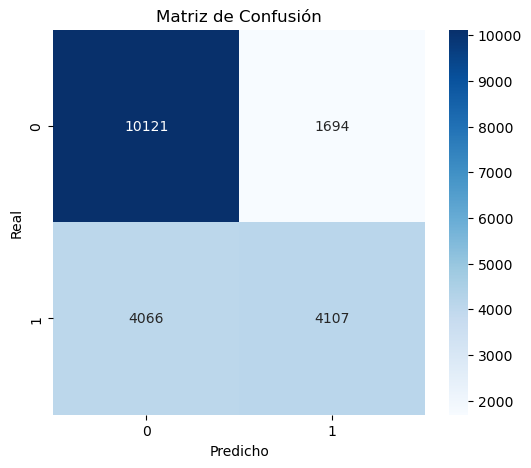


¡Ejemplo end-to-end completado! Stacking combina modelos base para mejor precisión en aprobación de crédito.
- Dataset: ~100k solicitudes sintéticas diarias con lógica realista.
- Preprocesamiento: Encoding/escalado para ML.
- Modelo: Stacking con RF, XGBoost, LR como bases; LR como meta para ensemble robusto.
- Evaluación: Métricas clave para clasificación binaria.
- Recomendación: En producción, usa cross-validation externa; integra SHAP para explicabilidad en decisiones crediticias.


Exception ignored in: <function ResourceTracker.__del__ at 0x105ad2c00>
Traceback (most recent call last):
  File "/opt/miniconda3/envs/myenv/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/miniconda3/envs/myenv/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/miniconda3/envs/myenv/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x10256ac00>
Traceback (most recent call last):
  File "/opt/miniconda3/envs/myenv/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/miniconda3/envs/myenv/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/miniconda3/envs/myenv/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function 

In [26]:


# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusión')
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.show()

print("\n¡Ejemplo end-to-end completado! Stacking combina modelos base para mejor precisión en aprobación de crédito.")
print("- Dataset: ~100k solicitudes sintéticas diarias con lógica realista.")
print("- Preprocesamiento: Encoding/escalado para ML.")
print("- Modelo: Stacking con RF, XGBoost, LR como bases; LR como meta para ensemble robusto.")
print("- Evaluación: Métricas clave para clasificación binaria.")
print("- Recomendación: En producción, usa cross-validation externa; integra SHAP para explicabilidad en decisiones crediticias.")